# NumPy × Linear Algebra — Interactive Notebook
**3Blue1Brown concepts → NumPy code → matplotlib plots**

Run each cell, tweak the values, and watch the plot update.

---

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

# ── shared dark style helpers ────────────────────────────────────
BG, PANEL  = '#0F172A', '#1E293B'
TEAL, BLUE = '#1D9E75', '#378ADD'
AMBER, CORAL, PURPLE = '#EF9F27', '#D85A30', '#7F77DD'
GRAY, WHITE, MUTED   = '#64748B', '#CDD6F4', '#94A3B8'

def style(ax, xlim=(-1,6), ylim=(-1,5), title=''):
    ax.set_facecolor(PANEL); ax.set_xlim(*xlim); ax.set_ylim(*ylim)
    ax.set_aspect('equal'); ax.axhline(0,color=GRAY,lw=0.8,zorder=0)
    ax.axvline(0,color=GRAY,lw=0.8,zorder=0)
    ax.grid(True,color='#263548',lw=0.6,zorder=0)
    ax.tick_params(colors=MUTED,labelsize=8)
    for s in ax.spines.values(): s.set_edgecolor(GRAY)
    if title: ax.set_title(title,color=WHITE,fontsize=11,pad=8,fontweight='bold')

def arrow(ax, start, end, color, lw=2.5, alpha=1.0, ls='-'):
    ax.annotate('', xy=end, xytext=start,
        arrowprops=dict(arrowstyle='-|>', color=color, lw=lw,
                        alpha=alpha, linestyle=ls, mutation_scale=14), zorder=5)

def label(ax, pos, text, color, fontsize=9, offset=(0.1,0.1)):
    ax.text(pos[0]+offset[0], pos[1]+offset[1], text,
            color=color, fontsize=fontsize, fontfamily='monospace', zorder=6)

print('Setup complete.')

Setup complete.


---
## 01 · Vectors

v + w          = [4 3]
2.5 * v       = [7.5 2.5]
||v||          = 3.162


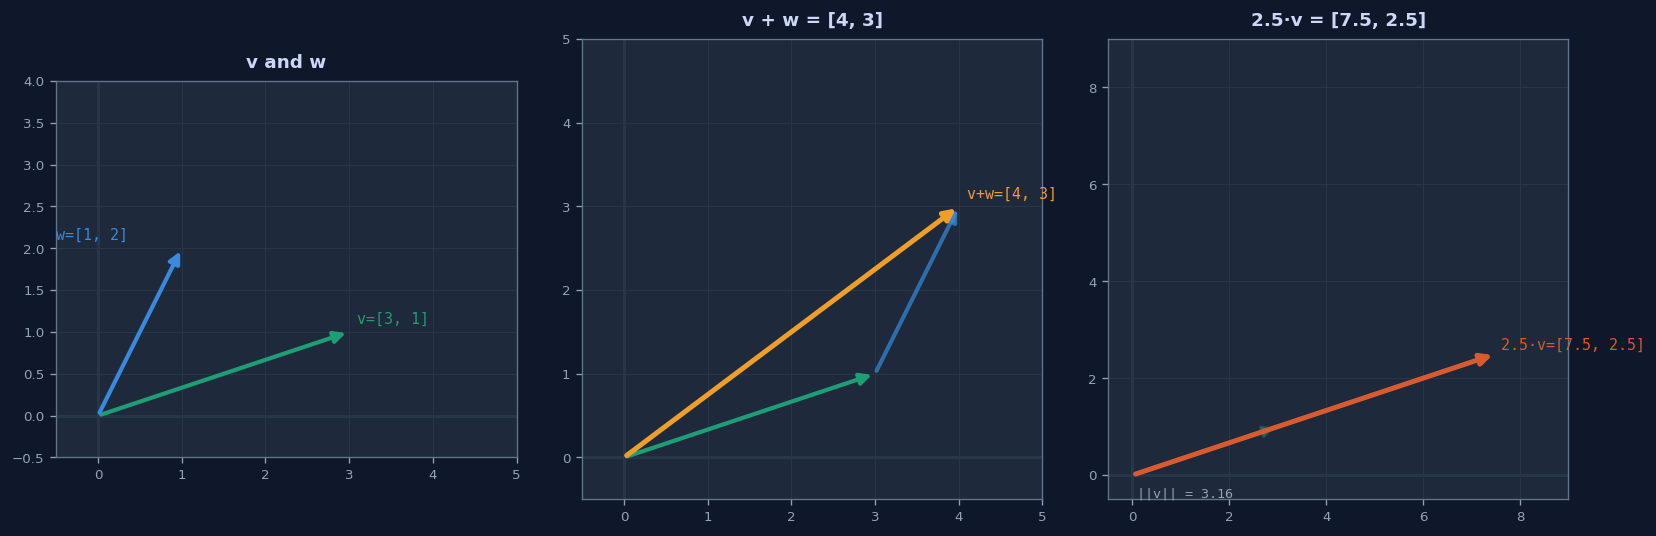

In [ ]:
# ── CHANGE THESE ─────────────────────────────────────────────────
v = np.array([3, 1])
w = np.array([1, 2])
scalar = 2.5
# ─────────────────────────────────────────────────────────────────

print(f'v + w          = {v + w}')
print(f'{scalar} * v       = {scalar * v}')
print(f'||v||          = {np.linalg.norm(v):.3f}')

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), facecolor=BG)

# Panel 1: v and w
ax = axes[0]; 
style(ax, (-0.5,5), (-0.5,4), 'v and w')
arrow(ax, [0,0], v, TEAL); arrow(ax, [0,0], w, BLUE)
label(ax, v, f'v={v.tolist()}', TEAL)
label(ax, w, f'w={w.tolist()}', BLUE, offset=(-1.5,0.1))

# Panel 2: tip-to-tail addition
ax = axes[1]; mx = max(v[0]+w[0], v[1]+w[1]) + 1
style(ax, (-0.5, mx), (-0.5, mx), f'v + w = {(v+w).tolist()}')
arrow(ax, [0,0], v, TEAL); arrow(ax, v, v+w, BLUE, alpha=0.7)
arrow(ax, [0,0], v+w, AMBER, lw=3)
label(ax, v+w, f'v+w={( v+w).tolist()}', AMBER)

# Panel 3: scalar multiply
ax = axes[2]; sv = scalar * v
style(ax, (-0.5, max(sv)+1.5), (-0.5, max(sv)+1.5), f'{scalar}·v = {sv.tolist()}')
arrow(ax, [0,0], v,  TEAL, alpha=0.4, lw=2)
arrow(ax, [0,0], sv, CORAL, lw=3)
label(ax, sv, f'{scalar}·v={sv.tolist()}', CORAL)
ax.text(0.1,-0.45, f'||v|| = {np.linalg.norm(v):.2f}', color=MUTED, fontsize=8, fontfamily='monospace')

plt.tight_layout(); plt.show()

---
## 02 · Basis Vectors

v = 3·î + 2·ĵ = [3 2]
1·b1 + 2·b2 = [0 3]


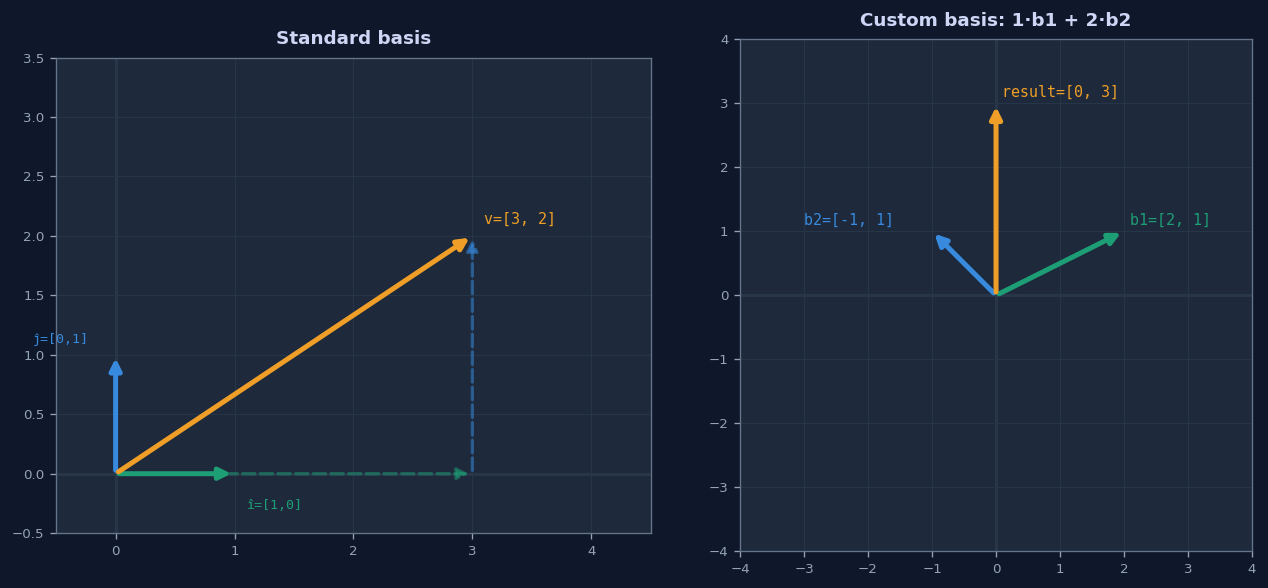

In [18]:
# ── CHANGE THESE ─────────────────────────────────────────────────
coeff_i = 3      # how many i-hats
coeff_j = 2      # how many j-hats
b1 = np.array([2, 1])    # custom basis vector 1
b2 = np.array([-1, 1])   # custom basis vector 2
cb1, cb2 = 1, 2           # coefficients in custom basis
# ─────────────────────────────────────────────────────────────────

i_hat = np.array([1, 0])
j_hat = np.array([0, 1])
v = coeff_i*i_hat + coeff_j*j_hat
print(f'v = {coeff_i}·î + {coeff_j}·ĵ = {v}')
print(f'{cb1}·b1 + {cb2}·b2 = {cb1*b1 + cb2*b2}')

fig, axes = plt.subplots(1, 2, figsize=(11, 5), facecolor=BG)

ax = axes[0]; style(ax, (-0.5,coeff_i+1.5), (-0.5,coeff_j+1.5), 'Standard basis')
arrow(ax, [0,0], i_hat, TEAL, lw=3); arrow(ax, [0,0], j_hat, BLUE, lw=3)
# decomposition steps
arrow(ax, [0,0], coeff_i*i_hat, TEAL, lw=2, alpha=0.5, ls='--')
arrow(ax, coeff_i*i_hat, v, BLUE, lw=2, alpha=0.5, ls='--')
arrow(ax, [0,0], v, AMBER, lw=3)
ax.text(1.1,-0.3, 'î=[1,0]', color=TEAL, fontsize=8, fontfamily='monospace')
ax.text(-0.7,1.1, 'ĵ=[0,1]', color=BLUE, fontsize=8, fontfamily='monospace')
label(ax, v, f'v={v.tolist()}', AMBER)

ax = axes[1]; cv = cb1*b1 + cb2*b2
lim = max(abs(np.concatenate([b1,b2,cv])))+1
style(ax, (-lim,lim), (-lim,lim), f'Custom basis: {cb1}·b1 + {cb2}·b2')
arrow(ax, [0,0], b1, TEAL, lw=3); arrow(ax, [0,0], b2, BLUE, lw=3)
arrow(ax, [0,0], cv, AMBER, lw=3)
label(ax, b1, f'b1={b1.tolist()}', TEAL)
label(ax, b2, f'b2={b2.tolist()}', BLUE, offset=(-2,0.1))
label(ax, cv, f'result={cv.tolist()}', AMBER)

plt.tight_layout(); plt.show()

---
## 03 · Linear Transformations

Matrix M:
[[ 0 -1]
 [ 1  0]]
M @ v = [-1  2]
det(M) = 1.000


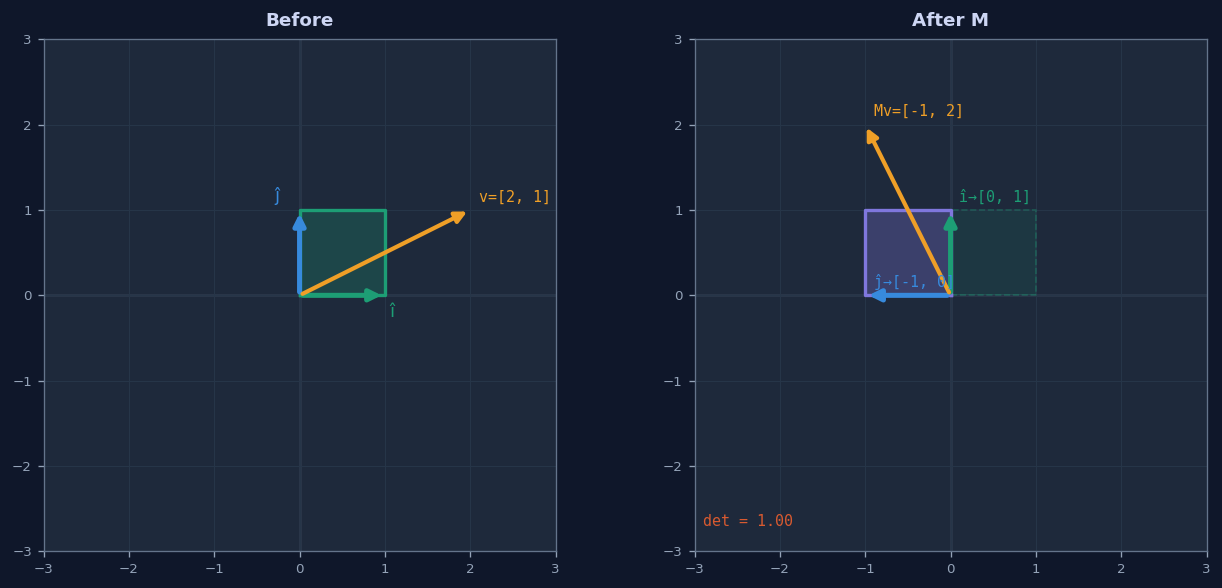

In [19]:
# ── CHANGE THIS MATRIX ───────────────────────────────────────────
M = np.array([[ 0, -1],   # rotation 90° — try [[2,0],[0,1]] for scale
              [ 1,  0]])
v_test = np.array([2, 1])
# ─────────────────────────────────────────────────────────────────

print(f'Matrix M:\n{M}')
print(f'M @ v = {M @ v_test}')
print(f'det(M) = {np.linalg.det(M):.3f}')

sq = np.array([[0,0],[1,0],[1,1],[0,1]], dtype=float)
sq_t = (M @ sq.T).T

fig, axes = plt.subplots(1, 2, figsize=(11, 5), facecolor=BG)

lim = max(3, abs(sq_t).max() + 1)
for ax, label_str in zip(axes, ['Before', f'After M']):
    style(ax, (-lim, lim), (-lim, lim), label_str)

# Before
ax = axes[0]
ax.fill(sq[:,0], sq[:,1], color=TEAL, alpha=0.25)
ax.plot(np.append(sq[:,0],sq[0,0]), np.append(sq[:,1],sq[0,1]), color=TEAL, lw=2)
arrow(ax, [0,0], [1,0], TEAL, lw=3); arrow(ax, [0,0], [0,1], BLUE, lw=3)
arrow(ax, [0,0], v_test, AMBER, lw=2.5)
ax.text(1.05,-0.25,'î',color=TEAL,fontsize=11); ax.text(-0.3,1.1,'ĵ',color=BLUE,fontsize=11)
label(ax, v_test, f'v={v_test.tolist()}', AMBER)

# After
ax = axes[1]
ax.fill(sq[:,0],   sq[:,1],   color=TEAL, alpha=0.12)   # ghost
ax.plot(np.append(sq[:,0],sq[0,0]), np.append(sq[:,1],sq[0,1]),
        color=TEAL, lw=1, ls='--', alpha=0.35)
ax.fill(sq_t[:,0], sq_t[:,1], color=PURPLE, alpha=0.3)
ax.plot(np.append(sq_t[:,0],sq_t[0,0]), np.append(sq_t[:,1],sq_t[0,1]), color=PURPLE, lw=2)
arrow(ax, [0,0], M[:,0], TEAL, lw=3); arrow(ax, [0,0], M[:,1], BLUE, lw=3)
arrow(ax, [0,0], M@v_test, AMBER, lw=2.5)
label(ax, M[:,0], f'î→{M[:,0].tolist()}', TEAL)
label(ax, M[:,1], f'ĵ→{M[:,1].tolist()}', BLUE)
label(ax, M@v_test, f'Mv={( M@v_test).tolist()}', AMBER)
ax.text(-lim+0.1,-lim+0.3, f'det = {np.linalg.det(M):.2f}',
        color=CORAL, fontsize=9, fontfamily='monospace')

plt.tight_layout(); plt.show()

---
## 04 · Matrix Multiplication = Composition

M1 @ v          = [1 0]
M2 @ (M1 @ v)   = [0 1]
(M2 @ M1) @ v   = [0 1]
Same result?    = True


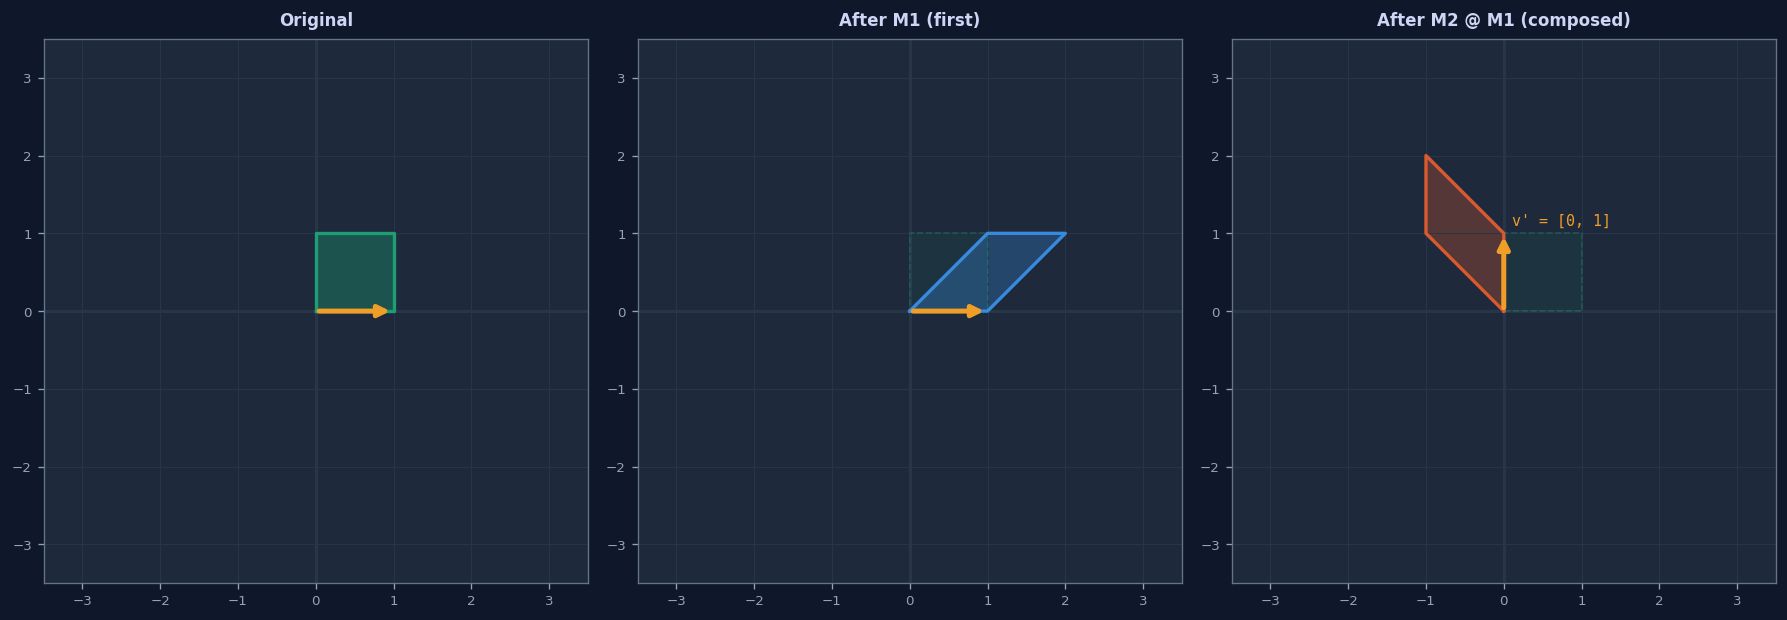

In [20]:
# ── CHANGE THESE ─────────────────────────────────────────────────
M1 = np.array([[1, 1], [0, 1]])   # applied FIRST  (shear)
M2 = np.array([[0,-1], [1, 0]])   # applied SECOND (rotate)
v = np.array([1, 0])
# ─────────────────────────────────────────────────────────────────

C = M2 @ M1
step = M2 @ (M1 @ v)
comp = C @ v
print(f'M1 @ v          = {M1 @ v}')
print(f'M2 @ (M1 @ v)   = {step}')
print(f'(M2 @ M1) @ v   = {comp}')
print(f'Same result?    = {np.allclose(step, comp)}')

sq = np.array([[0,0],[1,0],[1,1],[0,1]], dtype=float)
sq1 = (M1 @ sq.T).T
sqC = (C  @ sq.T).T

fig, axes = plt.subplots(1, 3, figsize=(15, 5), facecolor=BG)
lim = max(3, abs(sqC).max()+1.5)

for ax in axes: style(ax, (-lim,lim), (-lim,lim))
titles = ['Original', 'After M1 (first)', 'After M2 @ M1 (composed)']
colors = [TEAL, BLUE, CORAL]
squares = [sq, sq1, sqC]
for ax, title, color, s in zip(axes, titles, colors, squares):
    ax.set_title(title, color=WHITE, fontsize=10, pad=8, fontweight='bold')
    # ghost of original
    ax.fill(sq[:,0], sq[:,1], color=TEAL, alpha=0.1)
    ax.plot(np.append(sq[:,0],sq[0,0]), np.append(sq[:,1],sq[0,1]),
            color=TEAL, lw=1, ls='--', alpha=0.3)
    ax.fill(s[:,0], s[:,1], color=color, alpha=0.3)
    ax.plot(np.append(s[:,0],s[0,0]), np.append(s[:,1],s[0,1]), color=color, lw=2)

arrow(axes[0], [0,0], v,    AMBER, lw=3)
arrow(axes[1], [0,0], M1@v, AMBER, lw=3)
arrow(axes[2], [0,0], comp, AMBER, lw=3)
label(axes[2], comp, f'v\' = {comp.tolist()}', AMBER)

plt.tight_layout(); plt.show()

---
## 05 · Dot Product

np.dot(v, w)        = 8
Angle between them  = 45.00°
Projection of w→v   = [2. 0.]
Perpendicular?      = False


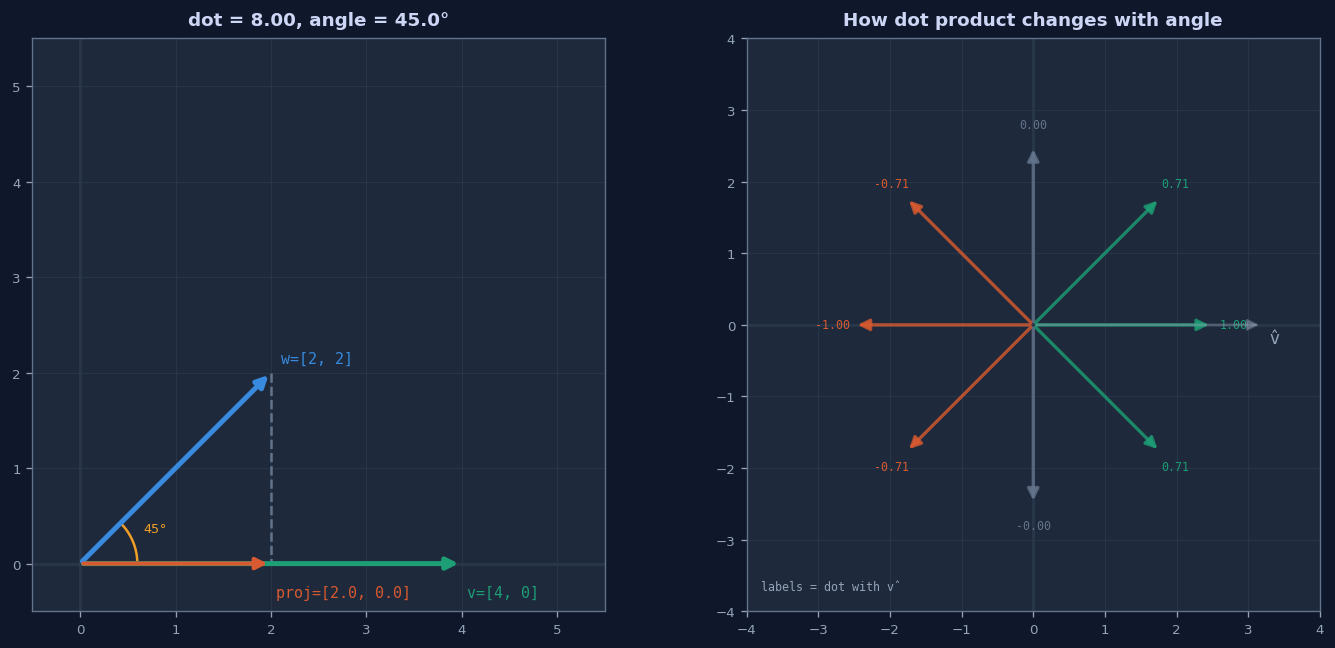

In [21]:
# ── CHANGE THESE ─────────────────────────────────────────────────
v = np.array([4, 0])
w = np.array([2, 2])
# ─────────────────────────────────────────────────────────────────

dot   = np.dot(v, w)
cos_a = dot / (np.linalg.norm(v) * np.linalg.norm(w))
angle = np.degrees(np.arccos(np.clip(cos_a, -1, 1)))
proj  = (dot / np.dot(v, v)) * v

print(f'np.dot(v, w)        = {dot}')
print(f'Angle between them  = {angle:.2f}°')
print(f'Projection of w→v   = {proj}')
print(f'Perpendicular?      = {np.isclose(dot, 0)}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), facecolor=BG)
lim = max(abs(v).max(), abs(w).max()) + 1.5

# Panel 1: vectors + angle + projection
ax = axes[0]; style(ax, (-0.5,lim), (-0.5,lim), f'dot = {dot:.2f}, angle = {angle:.1f}°')
arrow(ax, [0,0], v, TEAL, lw=3)
arrow(ax, [0,0], w, BLUE, lw=3)
# angle arc
a1 = np.arctan2(v[1],v[0]); a2 = np.arctan2(w[1],w[0])
th = np.linspace(min(a1,a2), max(a1,a2), 60)
ax.plot(0.6*np.cos(th), 0.6*np.sin(th), color=AMBER, lw=1.5)
mid = (a1+a2)/2
ax.text(0.72*np.cos(mid), 0.72*np.sin(mid)+0.05, f'{angle:.0f}°',
        color=AMBER, fontsize=8, fontfamily='monospace')
# projection
ax.plot([w[0],proj[0]], [w[1],proj[1]], color=GRAY, lw=1.5, ls='--')
arrow(ax, [0,0], proj, CORAL, lw=2.5)
label(ax, v, f'v={v.tolist()}', TEAL, offset=(0.05,-0.35))
label(ax, w, f'w={w.tolist()}', BLUE)
label(ax, proj, f'proj={np.round(proj,2).tolist()}', CORAL, offset=(0.05,-0.35))

# Panel 2: alignment chart at different angles
ax = axes[1]; style(ax, (-4,4), (-4,4), 'How dot product changes with angle')
ref = v / np.linalg.norm(v)
test_angles = np.arange(0, 360, 45)
for ang in test_angles:
    rad = np.radians(ang)
    u   = np.array([np.cos(rad), np.sin(rad)]) * 2.5
    d   = np.dot(ref, u/np.linalg.norm(u))
    col = TEAL if d > 0.1 else (CORAL if d < -0.1 else GRAY)
    arrow(ax, [0,0], u, col, lw=2, alpha=0.8)
    ax.text(u[0]*1.12, u[1]*1.12, f'{d:.2f}',
            color=col, fontsize=7, ha='center', va='center', fontfamily='monospace')
arrow(ax, [0,0], ref*3.2, MUTED, lw=1.5, alpha=0.4)
ax.text(3.3, -0.25, 'v̂', color=MUTED, fontsize=10)
ax.text(-3.8,-3.7, 'labels = dot with v̂', color=MUTED, fontsize=7, fontfamily='monospace')

plt.tight_layout(); plt.show()

---
## 06 · Determinant

Scale x2: det = 2.0000
Rotate 90°: det = 1.0000
Singular: det = 0.0000
Flip: det = -1.0000


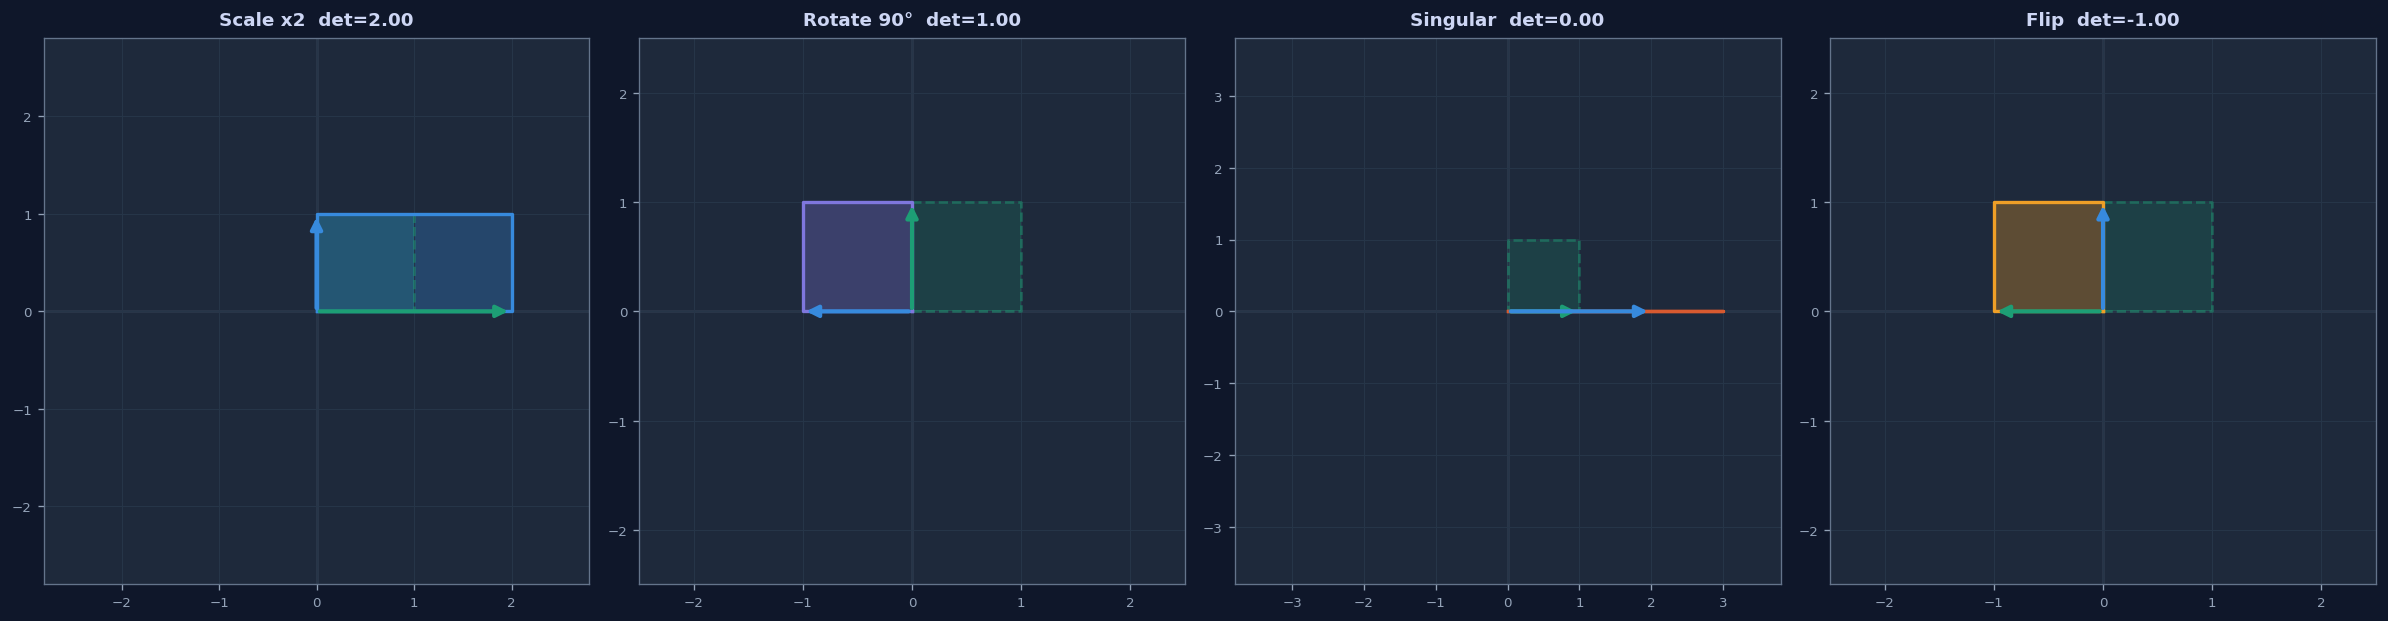

In [22]:
# ── CHANGE THESE MATRICES ────────────────────────────────────────
matrices = [
    (np.array([[2., 0.],[0., 1.]]), BLUE,   'Scale x2'),
    (np.array([[0.,-1.],[1., 0.]]), PURPLE, 'Rotate 90°'),
    (np.array([[1., 2.],[0., 0.]]), CORAL,  'Singular'),
    (np.array([[-1.,0.],[0., 1.]]), AMBER,  'Flip'),
]
# ─────────────────────────────────────────────────────────────────

sq = np.array([[0,0],[1,0],[1,1],[0,1]], dtype=float)

fig, axes = plt.subplots(1, len(matrices), figsize=(5*len(matrices), 5.5), facecolor=BG)
if len(matrices) == 1: axes = [axes]

for ax, (M, color, name) in zip(axes, matrices):
    det = np.linalg.det(M)
    sq_t = (M @ sq.T).T
    lim  = max(2.5, abs(sq_t).max() + 0.8)
    style(ax, (-lim,lim), (-lim,lim), f'{name}  det={det:.2f}')

    ax.fill(sq[:,0], sq[:,1], color=TEAL, alpha=0.2)
    ax.plot(np.append(sq[:,0],sq[0,0]), np.append(sq[:,1],sq[0,1]),
            color=TEAL, lw=1.5, ls='--', alpha=0.5)

    ax.fill(sq_t[:,0], sq_t[:,1], color=color, alpha=0.3)
    ax.plot(np.append(sq_t[:,0],sq_t[0,0]), np.append(sq_t[:,1],sq_t[0,1]),
            color=color, lw=2)

    arrow(ax, [0,0], M[:,0], TEAL, lw=2.5)
    arrow(ax, [0,0], M[:,1], BLUE, lw=2.5)
    print(f'{name}: det = {det:.4f}')

plt.tight_layout(); plt.show()

---
## 07 · Eigenvectors & Eigenvalues

Eigenvalues:  [3. 2.]
Eigenvectors (columns):
[[ 1.     -0.7071]
 [ 0.      0.7071]]
  M@e1 == λ1·e1 : True
  M@e2 == λ2·e2 : True


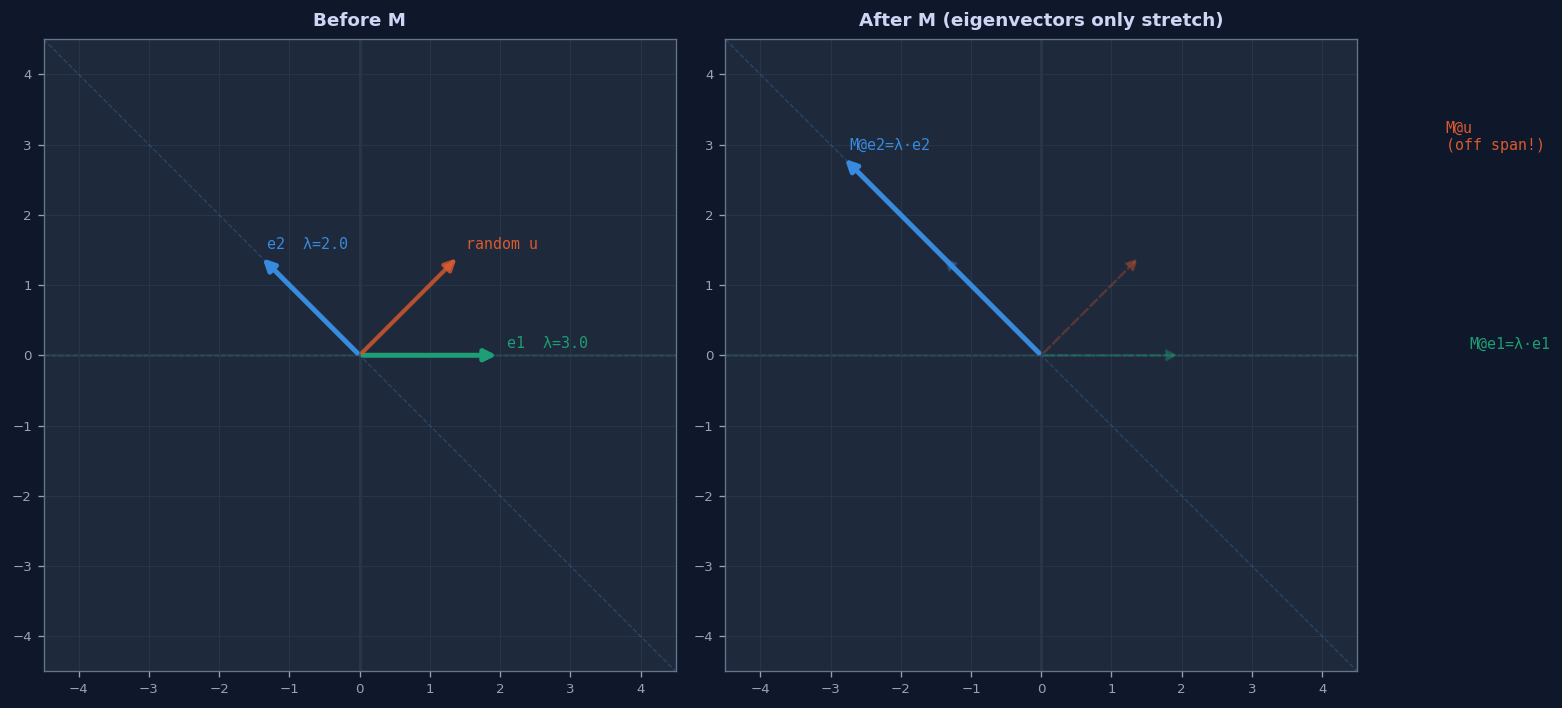

In [23]:
# ── CHANGE THIS MATRIX ───────────────────────────────────────────
M = np.array([[3., 1.],
              [0., 2.]])
# ─────────────────────────────────────────────────────────────────

vals, vecs = np.linalg.eig(M)
print(f'Eigenvalues:  {np.round(vals, 4)}')
print(f'Eigenvectors (columns):')
print(vecs.round(4))
for i in range(len(vals)):
    v_i = vecs[:, i]
    ok  = np.allclose(M @ v_i, vals[i] * v_i)
    print(f'  M@e{i+1} == λ{i+1}·e{i+1} : {ok}')

fig, axes = plt.subplots(1, 2, figsize=(13, 6), facecolor=BG)
lim = 4.5
t   = np.array([-lim, lim])
ev_colors = [TEAL, BLUE, PURPLE, AMBER]

for ax_idx, ax in enumerate(axes):
    style(ax, (-lim,lim), (-lim,lim),
          'Before M' if ax_idx==0 else 'After M (eigenvectors only stretch)')

    for i, (val, col) in enumerate(zip(vals, ev_colors)):
        e = vecs[:, i]
        # span line
        if abs(e[0]) > 1e-9:
            slope = e[1] / e[0]
            ax.plot(t, slope*t, color=col, lw=0.8, ls='--', alpha=0.3)

        if ax_idx == 0:
            arrow(ax, [0,0], e*2, col, lw=3)
            label(ax, e*2, f'e{i+1}  λ={val:.1f}', col)
        else:
            arrow(ax, [0,0], e*2,        col, lw=1.5, alpha=0.3, ls='--')
            arrow(ax, [0,0], (M@e)*2, col, lw=3)
            label(ax, (M@e)*2, f'M@e{i+1}=λ·e{i+1}', col)

    # random non-eigenvector
    rand = np.array([1., 1.])/np.sqrt(2) * 2
    if ax_idx == 0:
        arrow(ax, [0,0], rand,   CORAL, lw=2.5, alpha=0.8)
        label(ax, rand, 'random u', CORAL)
    else:
        rand_t = M @ (rand/2) * 2
        arrow(ax, [0,0], rand,   CORAL, lw=1.5, alpha=0.3, ls='--')
        arrow(ax, [0,0], rand_t, CORAL, lw=2.5)
        label(ax, rand_t, 'M@u\n(off span!)', CORAL)

plt.tight_layout(); plt.show()